# CXR-LT 2023

This notebook is the merged CXR-LT 2023 examination pass. It combines the original split/schema checks with the follow-on study, timeline, co-occurrence, view-conditioned, image-path, and report-linkage checks.

It reports both split-level summaries and global summaries that ignore the train/development/test split. Bar charts annotate each bar with both count and percentage: vertical bars show labels above the bar, and horizontal bars show labels at the bar end.


In [23]:
import os
os.environ['CURRENT_NOTEBOOK_NAME'] = 'cxr-lt-2023'
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from utils import *

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

root_dir, data_dir = get_notebook_paths()
cxr_lt_2023_dir = data_dir / "CXR-LT" / "cxr-lt-multi-label-long-tailed-classification-on-chest-x-rays-2.0.0" / "cxr-lt-2023"
mimic_cxr_dir = data_dir / "MIMIC-CXR"
mimic_cxr_jpg_dir = data_dir / "MIMIC-CXR-JPG"

print(f"root_dir: {root_dir}")
print(f"cxr_lt_2023_dir: {cxr_lt_2023_dir}")
print(f"mimic_cxr_dir exists: {mimic_cxr_dir.exists()}")
print(f"mimic_cxr_jpg_dir exists: {mimic_cxr_jpg_dir.exists()}")


In [24]:
CSV_FILES = {
    "train": "train.csv",
    "development": "development.csv",
    "test": "test.csv",
    "development_sample_submission": "development_sample_submission.csv",
    "test_sample_submission": "test_sample_submission.csv",
}

ANALYSIS_SPLIT_NAMES = ["train", "development", "test"]
ID_COLUMNS = BASE_ID_COLUMNS + ["path"]

datasets = load_csv_map(cxr_lt_2023_dir, CSV_FILES)

train_df = datasets["train"]
dev_df = datasets["development"]
test_df = datasets["test"]
dev_sample_sub_df = datasets["development_sample_submission"]
test_sample_sub_df = datasets["test_sample_submission"]

analysis_splits = {split_name: datasets[split_name] for split_name in ANALYSIS_SPLIT_NAMES}
submission_splits = {
    "development_sample_submission": dev_sample_sub_df,
    "test_sample_submission": test_sample_sub_df,
}

global_df = pd.concat(
    [df.assign(source_split=split_name) for split_name, df in analysis_splits.items()],
    ignore_index=True,
)
global_frames = {"global": global_df}

label_cols = label_columns(train_df)

print(f"Loaded {len(datasets)} files")
print(f"Detected {len(label_cols)} labels")
print(f"Global analysis rows: {len(global_df):,}")
label_cols


['Atelectasis',
 'Calcification of the Aorta',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Emphysema',
 'Enlarged Cardiomediastinum',
 'Fibrosis',
 'Fracture',
 'Hernia',
 'Infiltration',
 'Lung Lesion',
 'Lung Opacity',
 'Mass',
 'No Finding',
 'Nodule',
 'Pleural Effusion',
 'Pleural Other',
 'Pleural Thickening',
 'Pneumomediastinum',
 'Pneumonia',
 'Pneumoperitoneum',
 'Pneumothorax',
 'Subcutaneous Emphysema',
 'Support Devices',
 'Tortuous Aorta']

## Reusable helpers

Shared helpers now live in `utils.py` and are imported above.


## 1) Quick Split Overview

Start here to answer: how big are the splits, what fields exist, and where is metadata incomplete?


In [25]:
for split_name, df in analysis_splits.items():
    preview_dataset(split_name, df)

split_overview_df = build_split_overview(analysis_splits, label_cols)
display(split_overview_df)


,dicom_id,subject_id,study_id,ViewPosition,ViewCodeSequence_CodeMeaning,path,Atelectasis,Calcification of the Aorta,Cardiomegaly,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fracture,Hernia,Infiltration,Lung Lesion,Lung Opacity,Mass,No Finding,Nodule,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Subcutaneous Emphysema,Support Devices,Tortuous Aorta
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,PA,postero-anterior,files/p10/p10000032/s50414267/02aa804e-bde0afd...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,50414267,LATERAL,lateral,files/p10/p10000032/s50414267/174413ec-4ec4c1f...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,PA,postero-anterior,files/p10/p10000032/s53189527/2a2277a9-b0ded15...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,missing_count,missing_pct
ViewCodeSequence_CodeMeaning,11526,4.351914
ViewPosition,11050,4.172189


,dicom_id,subject_id,study_id,ViewPosition,ViewCodeSequence_CodeMeaning,path,Atelectasis,Calcification of the Aorta,Cardiomegaly,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fracture,Hernia,Infiltration,Lung Lesion,Lung Opacity,Mass,No Finding,Nodule,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Subcutaneous Emphysema,Support Devices,Tortuous Aorta
0,2833b85f-3bb4273f-cffd3794-2bf2cd57-7ddb3f5f,10002177,50520012,PA,postero-anterior,files/p10/p10002177/s50520012/2833b85f-3bb4273...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,7fdad032-90608fe2-c1f5a700-bf95f6f9-e9b0dbc7,10002177,50520012,LATERAL,lateral,files/p10/p10002177/s50520012/7fdad032-90608fe...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,8b88f03a-2004113d-4118def5-35820db5-d0913df8,10002221,53781756,NaN,NaN,files/p10/p10002221/s53781756/8b88f03a-2004113...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,missing_count,missing_pct
ViewCodeSequence_CodeMeaning,1564,4.253583
ViewPosition,1494,4.063205


,dicom_id,subject_id,study_id,ViewPosition,ViewCodeSequence_CodeMeaning,path,Atelectasis,Calcification of the Aorta,Cardiomegaly,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fracture,Hernia,Infiltration,Lung Lesion,Lung Opacity,Mass,No Finding,Nodule,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Subcutaneous Emphysema,Support Devices,Tortuous Aorta
0,d0b71acc-b5a62046-bbb5f6b8-7b173b85-65cdf738,10000935,50578979,AP,antero-posterior,files/p10/p10000935/s50578979/d0b71acc-b5a6204...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0
1,3be619d1-506a66cf-ff1ab8a1-2efb77bb-fe7d59fc,10000935,51178377,LATERAL,lateral,files/p10/p10000935/s51178377/3be619d1-506a66c...,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
2,9b314ad7-fbcb0422-6db62dfc-732858d0-a5527d8b,10000935,51178377,AP,antero-posterior,files/p10/p10000935/s51178377/9b314ad7-fbcb042...,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0


,missing_count,missing_pct
ViewCodeSequence_CodeMeaning,3407,4.513061
ViewPosition,3225,4.271976


,split,rows,unique_subjects,unique_studies,unique_dicoms,missing_ViewPosition,missing_ViewCodeMeaning,avg_labels_per_image,median_labels_per_image,No Finding_count,No Finding_rate_pct
0,train,264849,45766,160052,264849,11050,11526,2.399329,2.0,41869,15.808631
1,test,75492,13075,45492,75492,3225,3407,2.401619,2.0,12019,15.920892
2,development,36769,6538,22291,36769,1494,1564,2.398080,2.0,5826,15.844869


## 2) Global Dataset Statistics

These summaries disregard train/development/test and treat the CXR-LT 2023 labeled rows as one dataset.


In [26]:
global_overview_df = build_split_overview(global_frames, label_cols).rename(columns={"split": "scope"})
global_label_summary_df = summarize_labels(global_df, "global", label_cols)
global_view_position_summary_df = summarize_view_positions(global_df, "global", top_n=12).rename(columns={"split": "scope"})
global_no_finding_conflicts_df = summarize_no_finding_conflicts(global_frames, label_cols).rename(columns={"split": "scope"})

display(global_overview_df)

print("Most common global labels")
display(global_label_summary_df.head(10))

print("Rarest global labels")
display(global_label_summary_df.tail(10))

print("Global view-position distribution")
display(global_view_position_summary_df)

print("Global No Finding conflicts")
display(global_no_finding_conflicts_df)


,scope,rows,unique_subjects,unique_studies,unique_dicoms,missing_ViewPosition,missing_ViewCodeMeaning,avg_labels_per_image,median_labels_per_image,No Finding_count,No Finding_rate_pct
0,global,377110,65379,227835,377110,15769,16497,2.399666,2.0,59714,15.834637


,split,label,positive_count,positive_rate_pct
0,global,Support Devices,126776,33.617777
1,global,Lung Opacity,114056,30.244756
2,global,Cardiomegaly,109297,28.982790
3,global,Pleural Effusion,98707,26.174591
4,global,Atelectasis,96311,25.539233
5,global,Pneumonia,68327,18.118586
6,global,No Finding,59714,15.834637
7,global,Edema,55139,14.621463
8,global,Enlarged Cardiomediastinum,42960,11.391902
9,global,Consolidation,22763,6.036170


,split,label,positive_count,positive_rate_pct
16,global,Emphysema,5884,1.560287
17,global,Hernia,5838,1.548089
18,global,Tortuous Aorta,4915,1.303333
19,global,Pleural Thickening,4856,1.287688
20,global,Lung Lesion,3451,0.915118
21,global,Subcutaneous Emphysema,3424,0.907958
22,global,Fibrosis,1758,0.466177
23,global,Pneumomediastinum,1122,0.297526
24,global,Pleural Other,949,0.251651
25,global,Pneumoperitoneum,813,0.215587


,scope,ViewPosition,count,rate_pct
0,global,AP,147173,39.026544
1,global,PA,96161,25.499456
2,global,LATERAL,82853,21.970513
3,global,LL,35133,9.316380
4,global,Missing,15769,4.181539
5,global,PA LLD,4,0.001061
6,global,LAO,3,0.000796
7,global,RAO,3,0.000796
8,global,AP AXIAL,2,0.000530
9,global,XTABLE LATERAL,2,0.000530


,scope,rows_with_No Finding,rows_with_No Finding_and_other_label,conflict_rate_within_No Finding_pct
0,global,59714,11131,18.64052


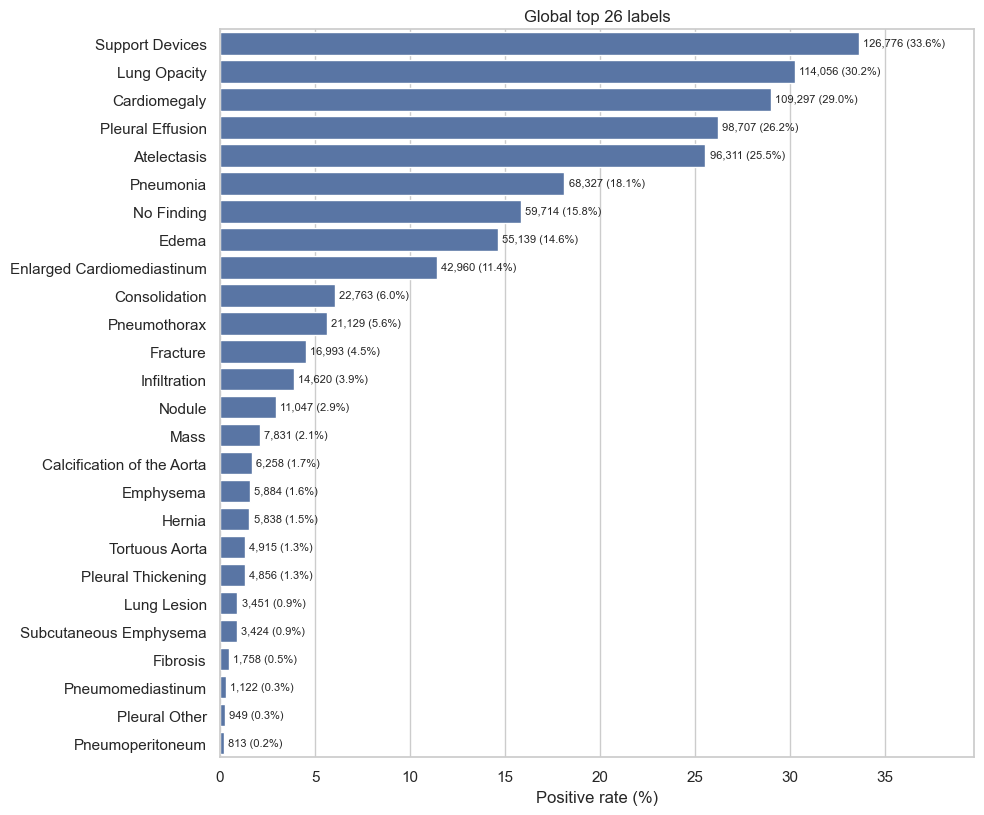

In [27]:
plot_global_label_prevalence(global_df, label_cols, top_n=26)

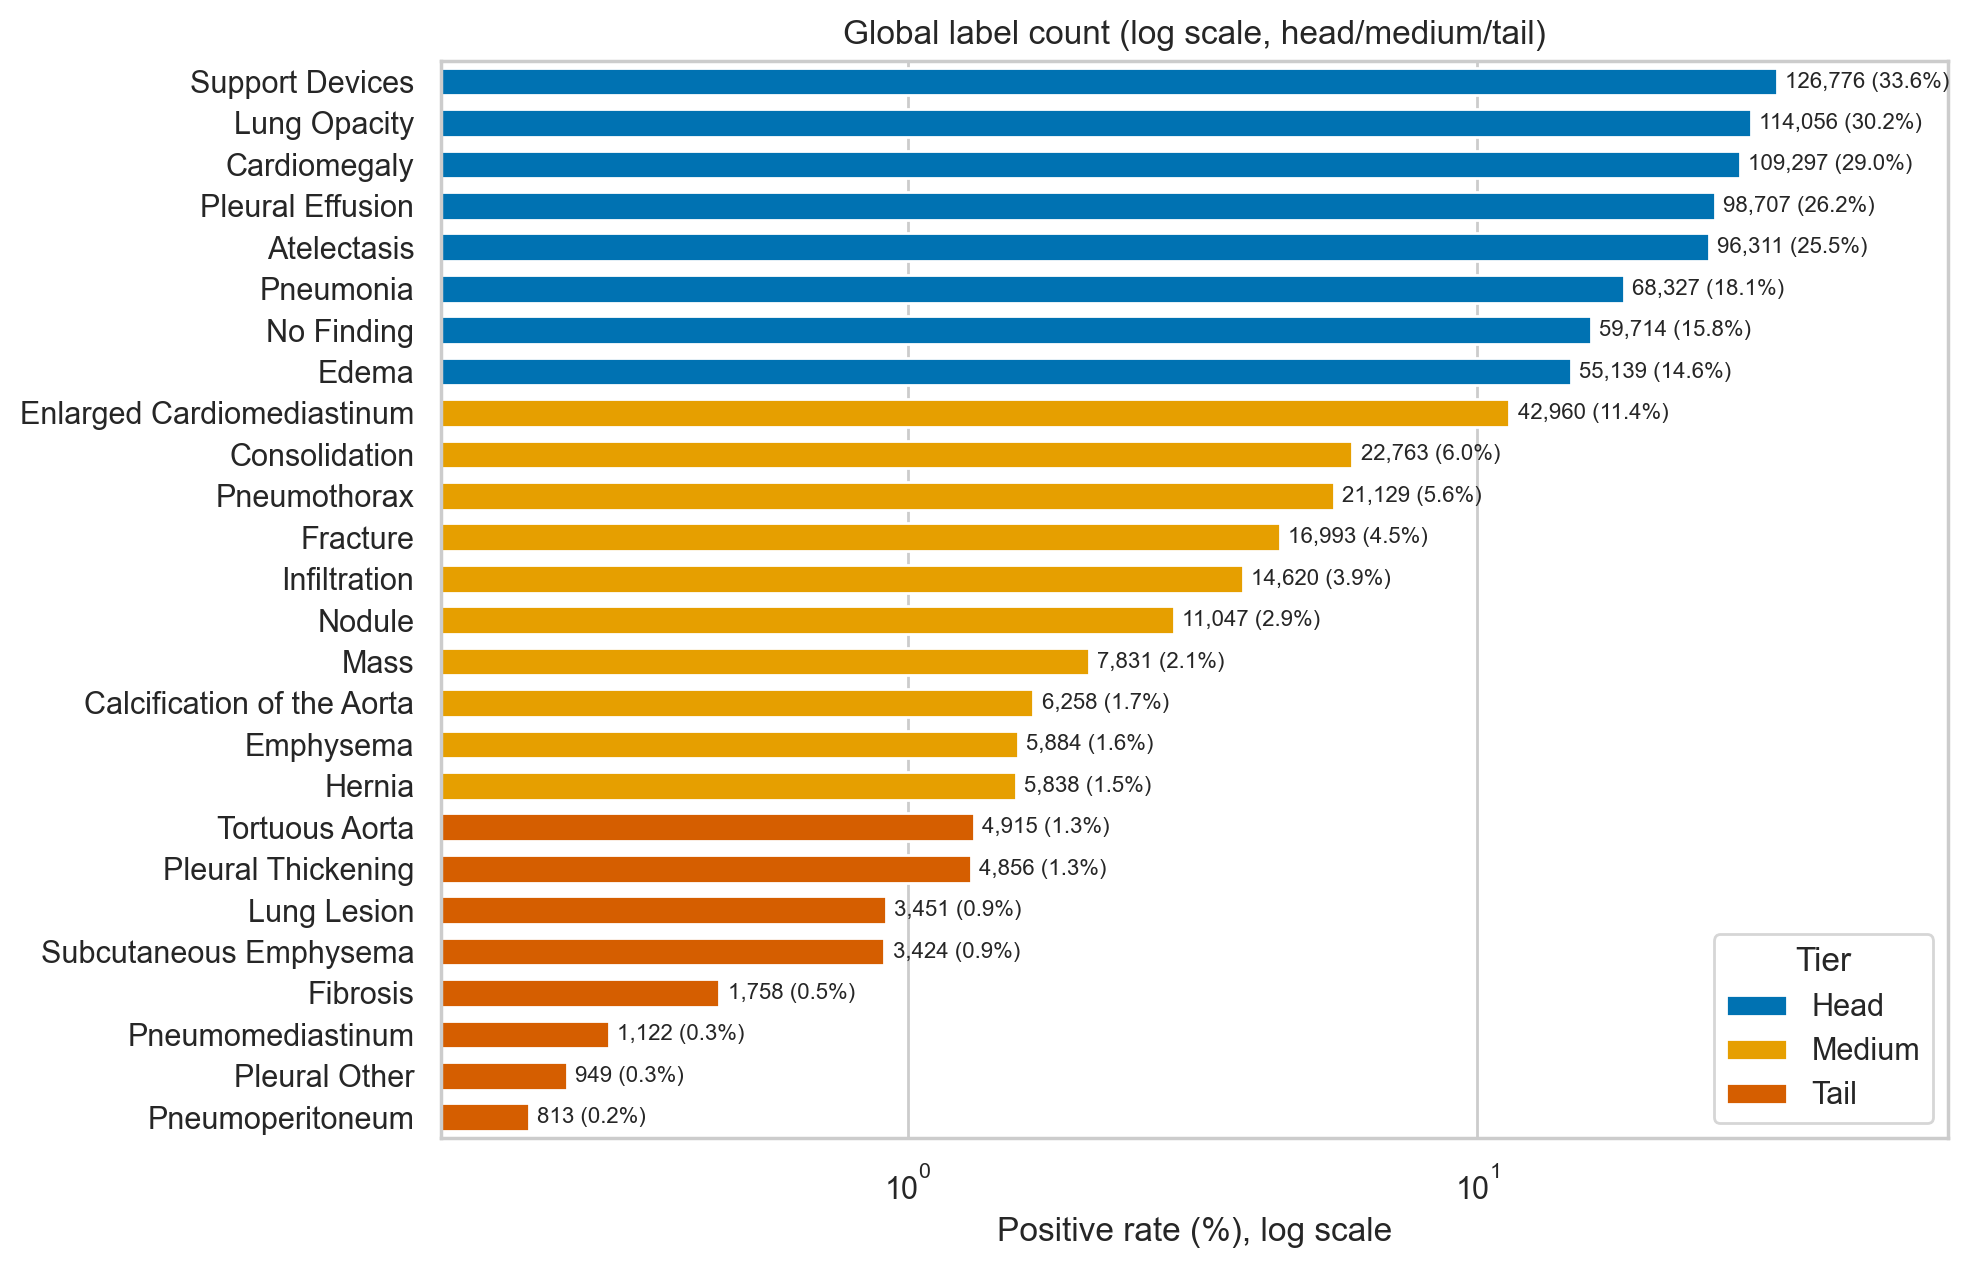

In [28]:
plot_global_label_prevalence_log_tiers(global_df, label_cols)

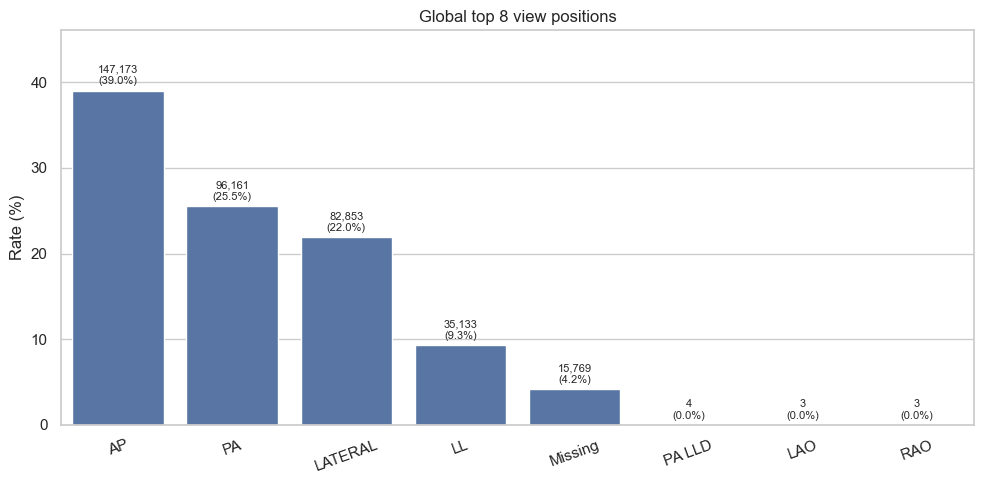

In [29]:
plot_global_view_positions(global_df, top_n=8)

## 3) Label Imbalance And Multi-Label Density

This is the part that tells you why the task is called long-tailed. Pay attention to the rarest labels and to how many findings co-occur on each image.


,split,label,positive_count,positive_rate_pct
78,global,Support Devices,126776,33.617777
79,global,Lung Opacity,114056,30.244756
80,global,Cardiomegaly,109297,28.982790
81,global,Pleural Effusion,98707,26.174591
82,global,Atelectasis,96311,25.539233
83,global,Pneumonia,68327,18.118586
84,global,No Finding,59714,15.834637
85,global,Edema,55139,14.621463
86,global,Enlarged Cardiomediastinum,42960,11.391902
87,global,Consolidation,22763,6.036170


,split,label,positive_count,positive_rate_pct
94,global,Emphysema,5884,1.560287
95,global,Hernia,5838,1.548089
96,global,Tortuous Aorta,4915,1.303333
97,global,Pleural Thickening,4856,1.287688
98,global,Lung Lesion,3451,0.915118
99,global,Subcutaneous Emphysema,3424,0.907958
100,global,Fibrosis,1758,0.466177
101,global,Pneumomediastinum,1122,0.297526
102,global,Pleural Other,949,0.251651
103,global,Pneumoperitoneum,813,0.215587


,split,label,positive_count,positive_rate_pct
0,train,Support Devices,89140,33.656914
1,train,Lung Opacity,79931,30.179838
2,train,Cardiomegaly,76900,29.035413
3,train,Pleural Effusion,69240,26.143199
4,train,Atelectasis,67597,25.522845
5,train,Pneumonia,48093,18.158649
6,train,No Finding,41869,15.808631
7,train,Edema,38574,14.564525
8,train,Enlarged Cardiomediastinum,30119,11.372140
9,train,Consolidation,16038,6.055526


,split,label,positive_count,positive_rate_pct
16,train,Emphysema,4255,1.606576
17,train,Hernia,4049,1.528796
18,train,Tortuous Aorta,3499,1.321130
19,train,Pleural Thickening,3369,1.272046
20,train,Lung Lesion,2533,0.956394
21,train,Subcutaneous Emphysema,2453,0.926188
22,train,Fibrosis,1158,0.437230
23,train,Pneumomediastinum,788,0.297528
24,train,Pleural Other,675,0.254862
25,train,Pneumoperitoneum,543,0.205022


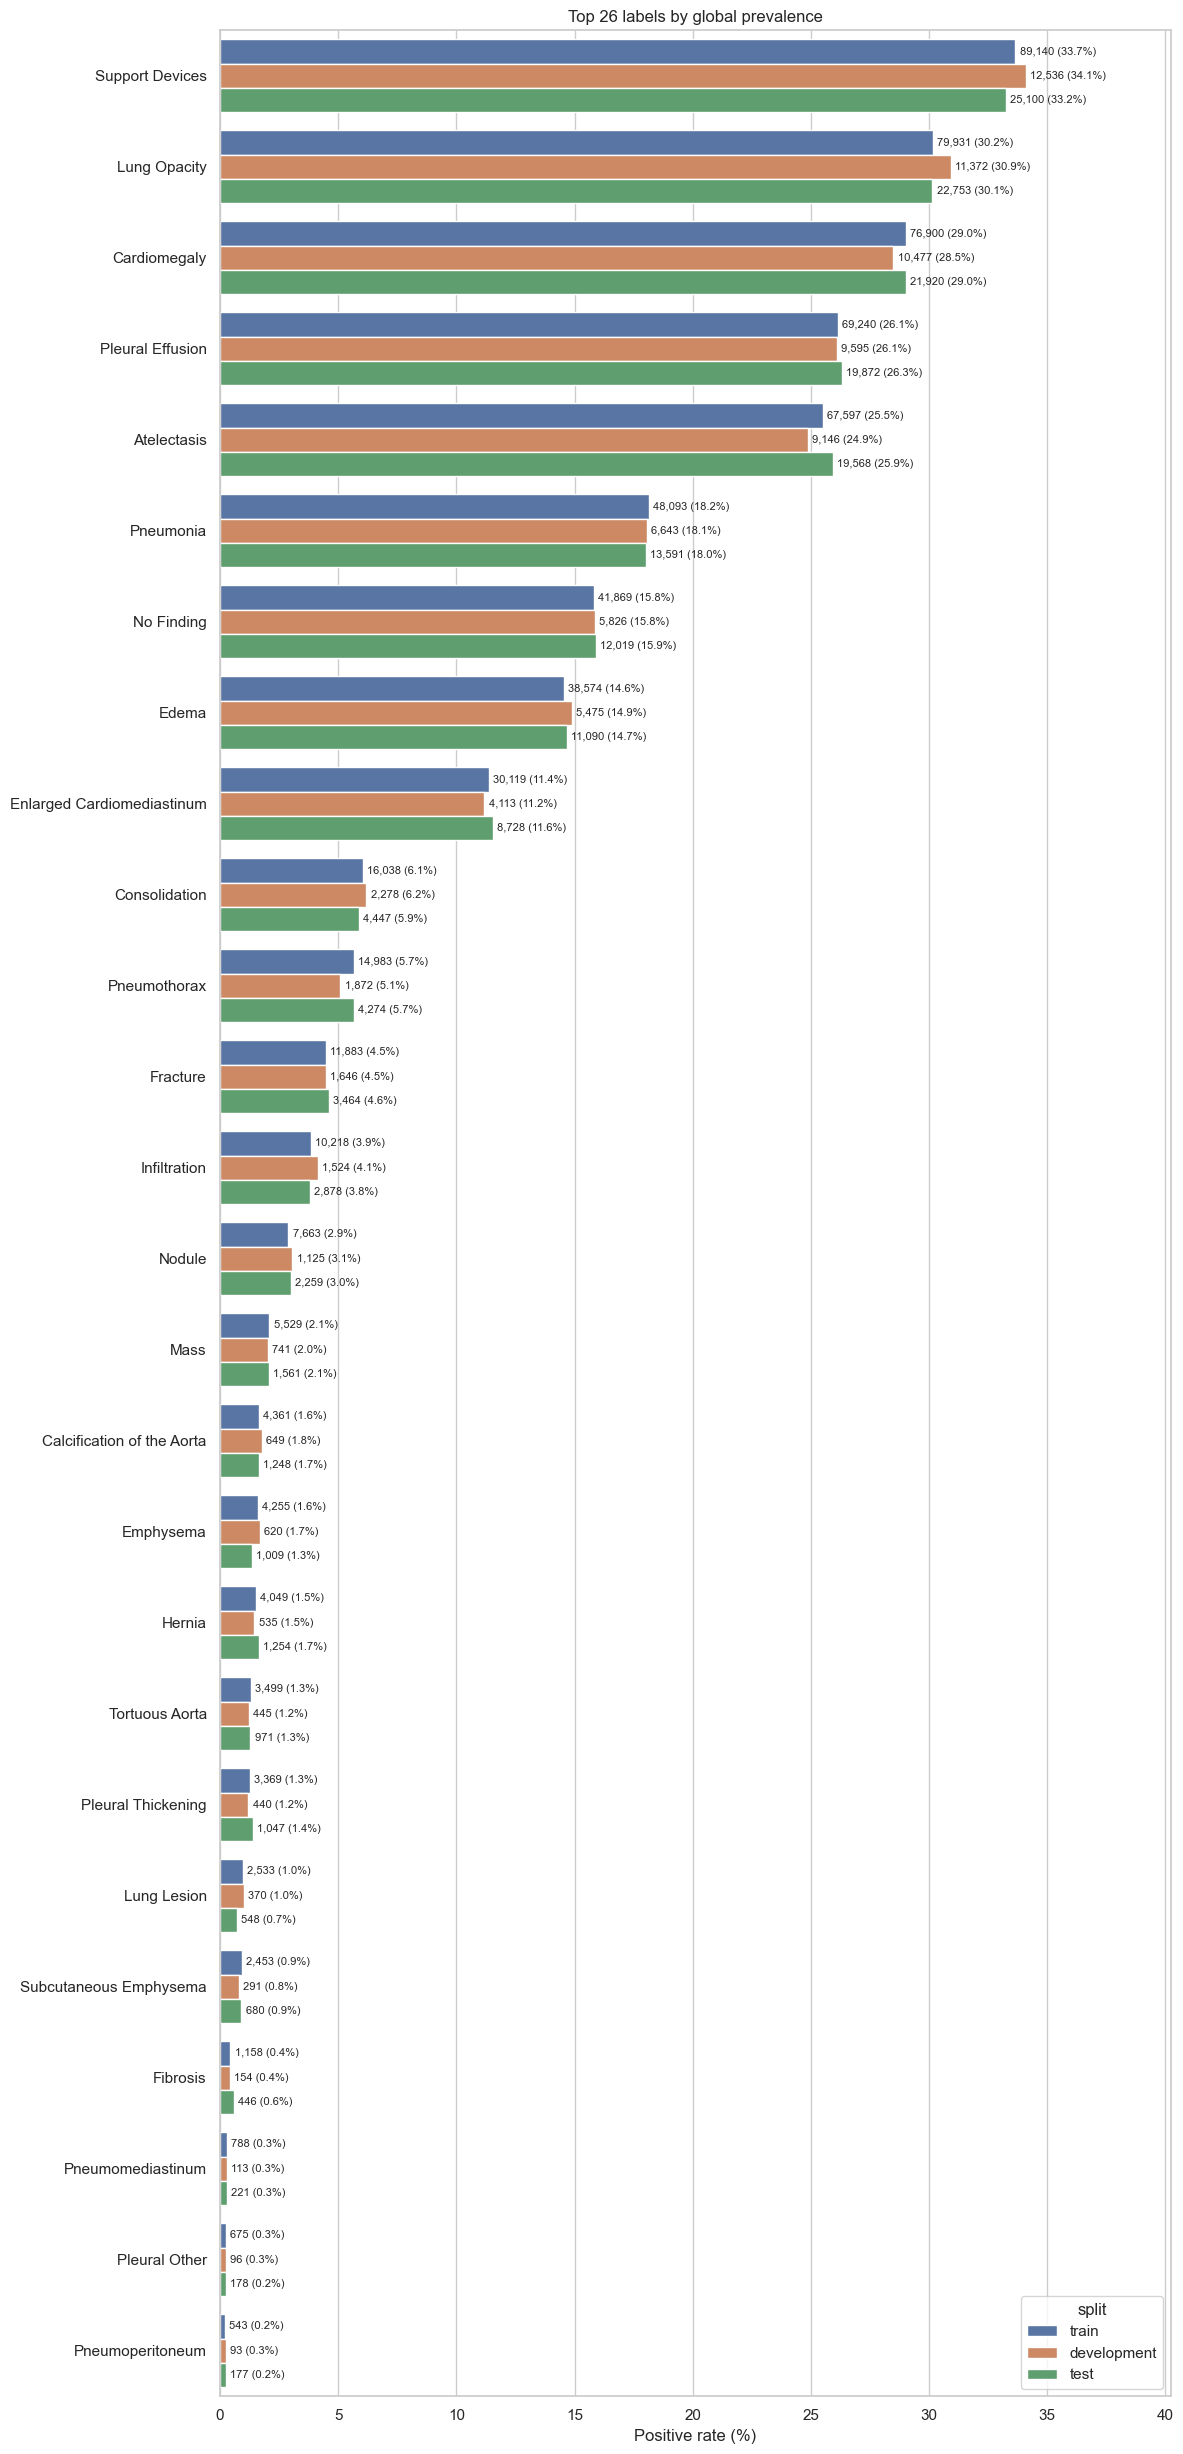

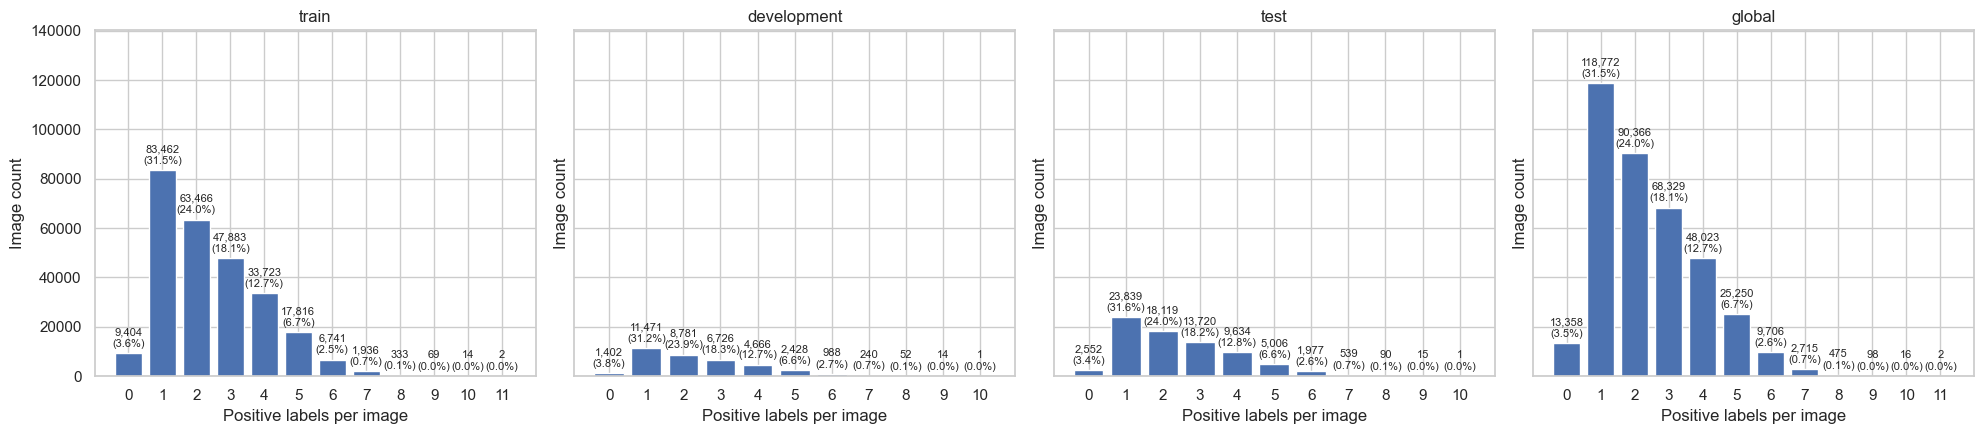

,split,rows_with_No Finding,rows_with_No Finding_and_other_label,conflict_rate_within_No Finding_pct
0,train,41869,7748,18.505338
1,development,5826,1136,19.498798
2,test,12019,2247,18.695399


In [30]:
label_summary_df = pd.concat(
    [summarize_labels(df, split_name, label_cols) for split_name, df in analysis_splits.items()],
    ignore_index=True,
)
label_summary_with_global_df = pd.concat([label_summary_df, global_label_summary_df], ignore_index=True)

display(label_summary_with_global_df.query("split == 'global'").head(10))
display(label_summary_with_global_df.query("split == 'global'").tail(10))

display(label_summary_df.query("split == 'train'").head(10))
display(label_summary_df.query("split == 'train'").tail(10))

plot_label_prevalence(analysis_splits, label_cols, reference_df=global_df, top_n=26)
plot_labels_per_image(analysis_splits, label_cols, include_global=True)

display(summarize_no_finding_conflicts(analysis_splits, label_cols))


## 4) View Metadata And Split Leakage Checks

For modeling, it helps to know whether view-position distribution shifts across splits and whether the same patient or study appears in multiple splits.


,split,ViewPosition,count,rate_pct
0,train,AP,103312,39.007888
1,train,PA,67559,25.508497
2,train,LATERAL,58018,21.906067
3,train,LL,24894,9.399318
4,train,Missing,11050,4.172189
5,train,PA LLD,4,0.001510
6,train,LAO,3,0.001133
7,train,RAO,3,0.001133
8,development,AP,14478,39.375561
9,development,PA,9305,25.306644


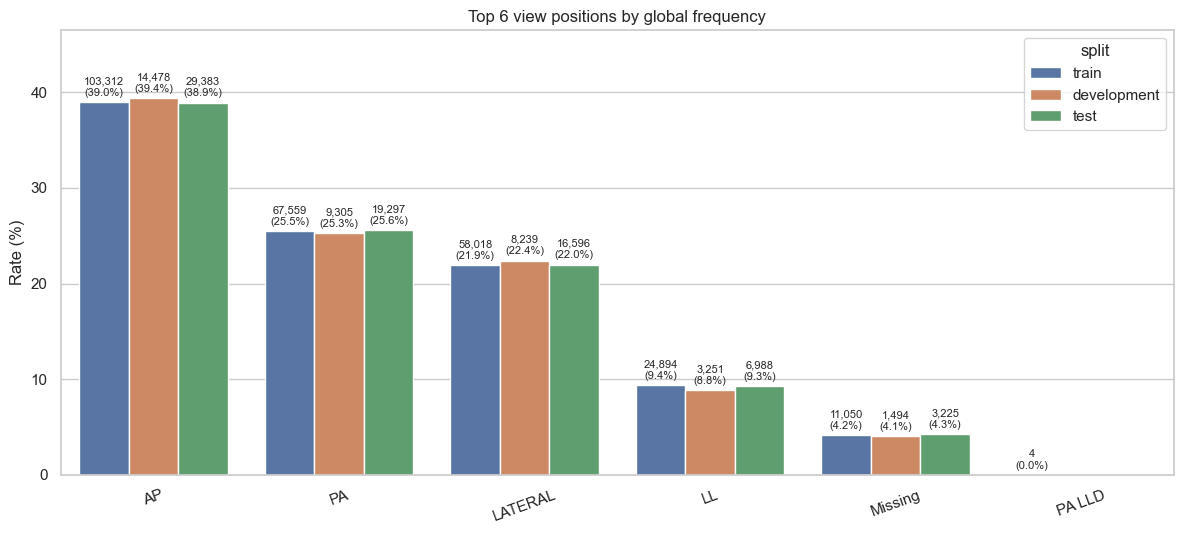

,train,development,test
train,45766.0,0.0,0.0
development,0.0,6538.0,0.0
test,0.0,0.0,13075.0


,train,development,test
train,160052.0,0.0,0.0
development,0.0,22291.0,0.0
test,0.0,0.0,45492.0


,train,development,test
train,264849.0,0.0,0.0
development,0.0,36769.0,0.0
test,0.0,0.0,75492.0


In [31]:
view_position_summary_df = pd.concat(
    [summarize_view_positions(df, split_name) for split_name, df in analysis_splits.items()],
    ignore_index=True,
)
view_position_summary_with_global_df = pd.concat(
    [view_position_summary_df, global_view_position_summary_df.rename(columns={"scope": "split"})],
    ignore_index=True,
)

display(view_position_summary_with_global_df)
plot_view_positions(analysis_splits, reference_df=global_df, top_n=6)

for overlap_key in ["subject_id", "study_id", "dicom_id"]:
    print(f"\nOverlap for {overlap_key}")
    display(compute_overlap(analysis_splits, overlap_key))


## 5) Sample Submission Sanity Checks

These files are handy for confirming the label order expected by the benchmark and for checking score ranges before writing an inference pipeline.


In [32]:
submission_summary_df = pd.concat(
    [summarize_submission_file(df, split_name, label_cols) for split_name, df in submission_splits.items()],
    ignore_index=True,
)
display(submission_summary_df)

for split_name, df in submission_splits.items():
    print(f"\n{split_name}")
    display(df.head(3))


,split,rows,label_columns_match_train,min_score,mean_score,max_score
0,development_sample_submission,36769,True,2.930000e-05,0.090590,0.99987
1,test_sample_submission,75492,True,2.701845e-07,0.499878,1.00000


,dicom_id,Atelectasis,Calcification of the Aorta,Cardiomegaly,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fracture,Hernia,Infiltration,Lung Lesion,Lung Opacity,Mass,No Finding,Nodule,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Subcutaneous Emphysema,Support Devices,Tortuous Aorta
0,2833b85f-3bb4273f-cffd3794-2bf2cd57-7ddb3f5f,0.033536,0.000823,0.069515,0.037374,0.018542,0.001762,0.115628,0.000941,0.029183,0.000827,0.034808,0.005435,0.244526,0.008278,0.327484,0.024222,0.059168,0.002028,0.006737,0.009162,0.232550,0.001842,0.066173,0.002313,0.019985,0.001036
1,7fdad032-90608fe2-c1f5a700-bf95f6f9-e9b0dbc7,0.017256,0.001685,0.057716,0.034736,0.011108,0.001892,0.145695,0.001276,0.034275,0.000956,0.026922,0.005146,0.197133,0.008934,0.387699,0.025641,0.027894,0.002538,0.006239,0.008972,0.229188,0.001278,0.037816,0.001514,0.034026,0.000951
2,8b88f03a-2004113d-4118def5-35820db5-d0913df8,0.031781,0.005160,0.091920,0.012458,0.013892,0.001624,0.090124,0.001223,0.049956,0.009194,0.050405,0.008491,0.106392,0.020967,0.374999,0.039554,0.013705,0.002365,0.009213,0.001864,0.210702,0.000764,0.007283,0.000721,0.056302,0.014445


,dicom_id,Atelectasis,Calcification of the Aorta,Cardiomegaly,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fracture,Hernia,Infiltration,Lung Lesion,Lung Opacity,Mass,No Finding,Nodule,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Subcutaneous Emphysema,Support Devices,Tortuous Aorta
0,d0b71acc-b5a62046-bbb5f6b8-7b173b85-65cdf738,0.044621,0.453646,0.053234,0.914087,0.756277,0.710636,0.201749,0.005243,0.966997,0.786332,0.074850,0.232403,0.734478,0.730561,0.515662,0.441672,0.405095,0.892778,0.269822,0.360429,0.671562,0.752237,0.705626,0.420611,0.795566,0.222684
1,3be619d1-506a66cf-ff1ab8a1-2efb77bb-fe7d59fc,0.436481,0.322232,0.614867,0.201023,0.467760,0.785392,0.591890,0.864125,0.514562,0.455972,0.442398,0.535389,0.228226,0.281679,0.767291,0.243542,0.175613,0.497524,0.063880,0.073988,0.994118,0.822464,0.407094,0.654748,0.909375,0.653350
2,9b314ad7-fbcb0422-6db62dfc-732858d0-a5527d8b,0.240715,0.101297,0.071512,0.349937,0.548107,0.555194,0.098996,0.782660,0.072775,0.165593,0.968731,0.273845,0.745644,0.092066,0.028868,0.997847,0.216771,0.169473,0.513566,0.419945,0.985205,0.264108,0.394382,0.772200,0.690808,0.977312


## 6) Study-Level Aggregation

This checks whether a `study_id` usually has a frontal view, a lateral view, or both. This matters for multi-view fusion because the image-level rows are not the same unit as a clinical exam.


,split,studies,single_image_studies_count,single_image_studies_pct,median_images_per_study,frontal_and_lateral_studies_count,frontal_and_lateral_studies_pct,pa_and_lateral_studies_pct,ap_and_lateral_studies_pct,median_positive_labels_per_study
0,train,160052,72101,45.048484,2.0,73910,46.178742,37.455952,8.810262,2.0
1,development,22291,10136,45.471266,2.0,10264,46.045489,37.073258,9.052981,2.0
2,test,45492,20438,44.926580,2.0,21064,46.302647,37.472523,8.885079,2.0


,scope,studies,single_image_studies_count,single_image_studies_pct,median_images_per_study,frontal_and_lateral_studies_count,frontal_and_lateral_studies_pct,pa_and_lateral_studies_pct,ap_and_lateral_studies_pct,median_positive_labels_per_study
0,global,227835,102675,45.065508,2.0,105238,46.190445,37.421818,8.848948,2.0


,subject_id,study_id,image_count,view_combo,has_frontal_and_lateral,positive_labels_per_study
0,10000032,50414267,2,LATERAL + PA,True,3
1,10000032,53189527,2,LATERAL + PA,True,1
2,10000032,53911762,2,AP,False,1
3,10000032,56699142,1,AP,False,1
4,10000764,57375967,3,AP + LATERAL,True,3
5,10000898,50771383,2,LATERAL + PA,True,1
6,10000898,54205396,3,LATERAL + PA,True,1
7,10000935,50578979,1,AP,False,3
8,10000935,51178377,2,AP + LATERAL,True,3
9,10000935,55697293,2,LL + PA,True,2


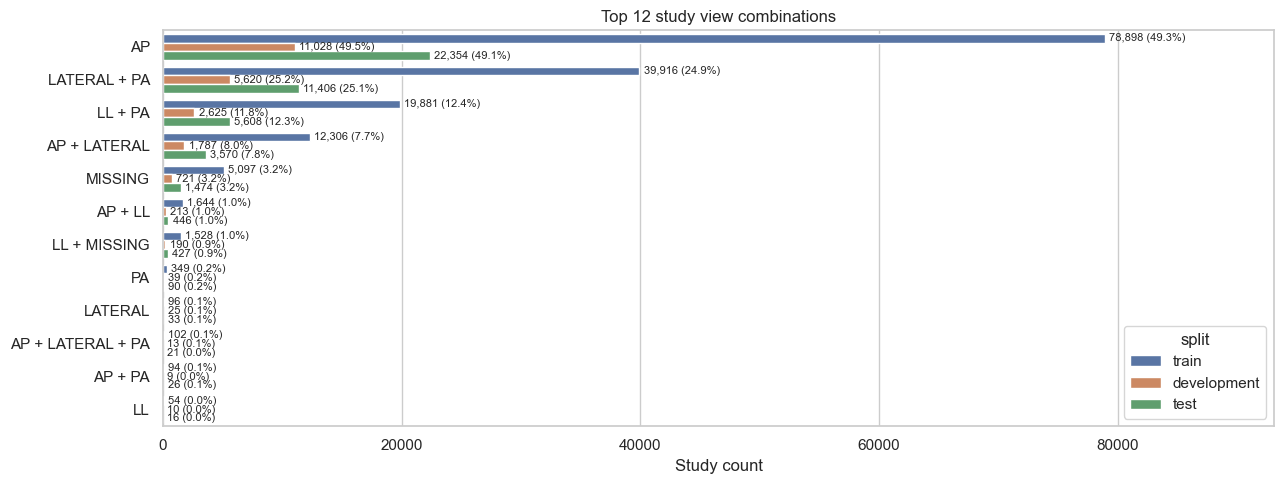

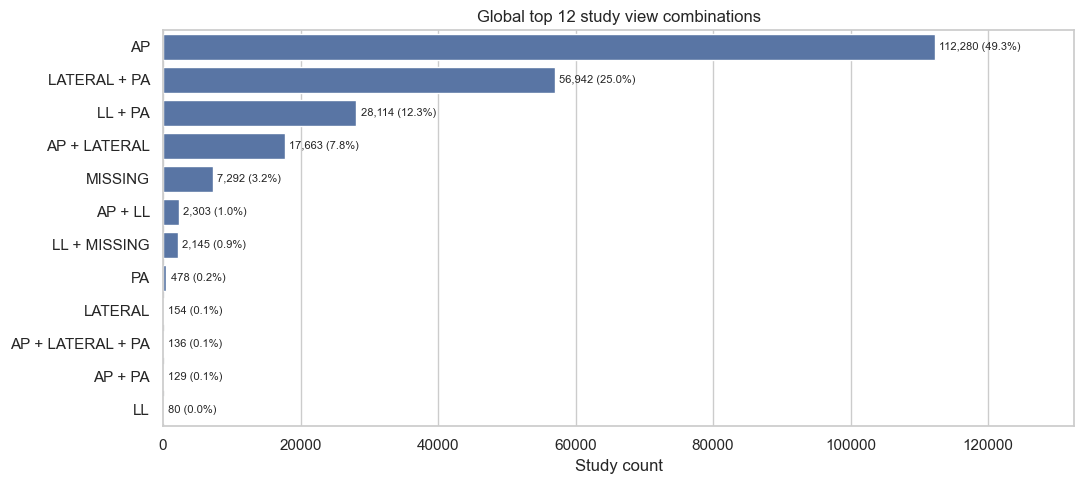

In [33]:
study_table_df, study_view_summary_df = summarize_study_views(analysis_splits, label_cols)
global_study_table_df, global_study_view_summary_df = summarize_study_views(global_frames, label_cols)
global_study_view_summary_df = global_study_view_summary_df.rename(columns={"split": "scope"})

display(study_view_summary_df)
display(global_study_view_summary_df)

display(
    global_study_table_df
    [
        [
            "subject_id",
            "study_id",
            "image_count",
            "view_combo",
            "has_frontal_and_lateral",
            "positive_labels_per_study",
        ]
    ]
    .head(10)
)

plot_top_view_combos(study_table_df, top_n=12)
plot_global_top_view_combos(global_study_table_df, top_n=12)


## 7) Patient Timeline Behavior

The CXR-LT CSVs do not include acquisition time, so this joins MIMIC-CXR-JPG metadata when available. MIMIC dates are shifted, but within-patient ordering and intervals are still useful for repeat-exam analysis.


In [34]:
metadata_df, metadata_path = load_first_existing(
    [
        mimic_cxr_jpg_dir / "mimic-cxr-2.0.0-metadata.csv.gz",
        mimic_cxr_jpg_dir / "mimic-cxr-2.0.0-metadata.csv",
    ]
)

if metadata_df is None:
    print("MIMIC-CXR-JPG metadata was not found. Timeline cells will fall back to study_id ordering.")
    metadata_columns = ["dicom_id", "study_datetime"]
    metadata_for_join = pd.DataFrame(columns=metadata_columns)
else:
    print(f"Loaded metadata: {metadata_path}")
    metadata_df["study_datetime"] = parse_mimic_study_datetime(metadata_df)
    metadata_columns = [
        column
        for column in [
            "dicom_id",
            "StudyDate",
            "StudyTime",
            "study_datetime",
            "PerformedProcedureStepDescription",
            "ProcedureCodeSequence_CodeMeaning",
            "Rows",
            "Columns",
        ]
        if column in metadata_df.columns
    ]
    metadata_for_join = metadata_df[metadata_columns].copy()

all_labeled_images_df = global_df.merge(metadata_for_join, on="dicom_id", how="left")

print(f"Rows with parsed study_datetime: {all_labeled_images_df['study_datetime'].notna().sum():,} / {len(all_labeled_images_df):,}")
display(all_labeled_images_df.head(3))


,dicom_id,subject_id,study_id,ViewPosition,ViewCodeSequence_CodeMeaning,path,Atelectasis,Calcification of the Aorta,Cardiomegaly,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fracture,Hernia,Infiltration,Lung Lesion,Lung Opacity,Mass,No Finding,Nodule,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Subcutaneous Emphysema,Support Devices,Tortuous Aorta,source_split,StudyDate,StudyTime,study_datetime,PerformedProcedureStepDescription,ProcedureCodeSequence_CodeMeaning,Rows,Columns
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,PA,postero-anterior,files/p10/p10000032/s50414267/02aa804e-bde0afd...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,train,21800506,213014.531,2180-05-06 21:30:14,CHEST (PA AND LAT),CHEST (PA AND LAT),3056,2544
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,50414267,LATERAL,lateral,files/p10/p10000032/s50414267/174413ec-4ec4c1f...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,train,21800506,213014.531,2180-05-06 21:30:14,CHEST (PA AND LAT),CHEST (PA AND LAT),3056,2544
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,PA,postero-anterior,files/p10/p10000032/s53189527/2a2277a9-b0ded15...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,train,21800626,165500.312,2180-06-26 16:55:00,CHEST (PA AND LAT),CHEST (PA AND LAT),3056,2544


In [35]:
study_timeline_df = build_study_timeline(all_labeled_images_df, label_cols, scope_columns=["source_split"])
global_study_timeline_df = build_study_timeline(all_labeled_images_df, label_cols)

patient_timeline_summary_df, split_patient_summary_df = summarize_patient_timelines(
    study_timeline_df,
    scope_columns=["source_split"],
)
global_patient_timeline_summary_df, global_patient_summary_df = summarize_patient_timelines(global_study_timeline_df)

split_patient_summary_df = split_patient_summary_df.rename(columns={"source_split": "split"})

display(split_patient_summary_df)
display(global_patient_summary_df)

display(
    global_patient_timeline_summary_df
    .sort_values(["study_count", "span_days"], ascending=[False, False])
    .head(10)
)


,split,patients,patients_with_multiple_studies,median_studies_per_patient,max_studies_per_patient,median_span_days,max_span_days,multiple_study_patient_pct
0,development,6538,3242,1.0,80,0.0000,1842.605671,49.587030
1,test,13075,6468,1.0,131,0.0000,1845.636748,49.468451
2,train,45766,22974,2.0,158,0.0911,1846.212303,50.198838


,scope,patients,patients_with_multiple_studies,median_studies_per_patient,max_studies_per_patient,median_span_days,max_span_days,multiple_study_patient_pct
0,global,65379,32684,1.0,158,0.0,1846.212303,49.991588


,subject_id,study_count,first_study_datetime,last_study_datetime,total_images,span_days
42053,16454913,158,2144-06-30 14:40:38,2146-06-26 04:44:30,174,725.586019
38717,15936063,131,2161-02-05 15:09:55,2164-08-22 10:04:33,142,1293.787940
54221,18295542,127,2157-11-07 22:44:17,2161-12-31 14:02:37,131,1514.637731
13258,12043836,124,2135-10-29 18:22:24,2139-09-29 12:59:46,167,1430.775949
63236,19674244,108,2193-10-28 16:01:58,2197-01-02 05:18:06,130,1161.552870
37160,15689523,104,2158-03-20 12:39:57,2159-09-15 16:33:08,119,544.161933
47425,17277688,96,2184-02-12 14:36:11,2186-11-13 17:49:48,113,1005.134456
43412,16662316,95,2174-12-08 01:06:57,2178-05-16 02:27:54,169,1255.056215
11071,11717909,95,2129-09-12 20:50:52,2132-02-21 10:40:56,114,891.576435
4532,10699336,89,2158-01-08 05:52:15,2158-04-16 12:21:40,98,98.270428


In [36]:
top_patient_row = (
    global_patient_timeline_summary_df
    .sort_values(["study_count", "span_days"], ascending=[False, False])
    .head(1)
)

if top_patient_row.empty:
    print("No patient timeline rows available.")
else:
    top_subject_id = top_patient_row.iloc[0]["subject_id"]
    print(f"Example repeat-exam patient: subject_id={top_subject_id}")
    display(
        global_study_timeline_df
        .query("subject_id == @top_subject_id")
        [
            [
                "subject_id",
                "study_id",
                "study_datetime",
                "days_since_previous_study",
                "image_count",
                "view_combo",
                "positive_labels_per_study",
            ]
        ]
    )


,subject_id,study_id,study_datetime,days_since_previous_study,image_count,view_combo,positive_labels_per_study
147544,16454913,55797204,2144-06-30 14:40:38,NaN,2,LATERAL + PA,1
147607,16454913,59642620,2144-07-08 15:43:30,8.043657,1,AP,1
147562,16454913,56858300,2144-08-03 12:17:17,25.856794,2,AP + LATERAL,2
147579,16454913,58035269,2144-10-06 15:37:37,64.139120,1,AP,3
147461,16454913,50348196,2144-10-07 02:05:50,0.436262,1,AP,0
...,...,...,...,...,...,...,...
147513,16454913,53712624,2146-06-15 00:33:37,3.570139,1,AP,5
147516,16454913,53804071,2146-06-21 16:24:19,6.660208,1,AP,5
147470,16454913,50537382,2146-06-23 05:40:00,1.552558,1,AP,5
147525,16454913,54295931,2146-06-25 10:04:34,2.183727,2,AP,1


## 8) Global Label Co-Occurrence And Correlations

These checks disregard split and use the complete labeled CXR-LT 2023 dataset. The correlation heatmap uses Pearson correlation on binary labels, which is the phi coefficient for two binary variables.


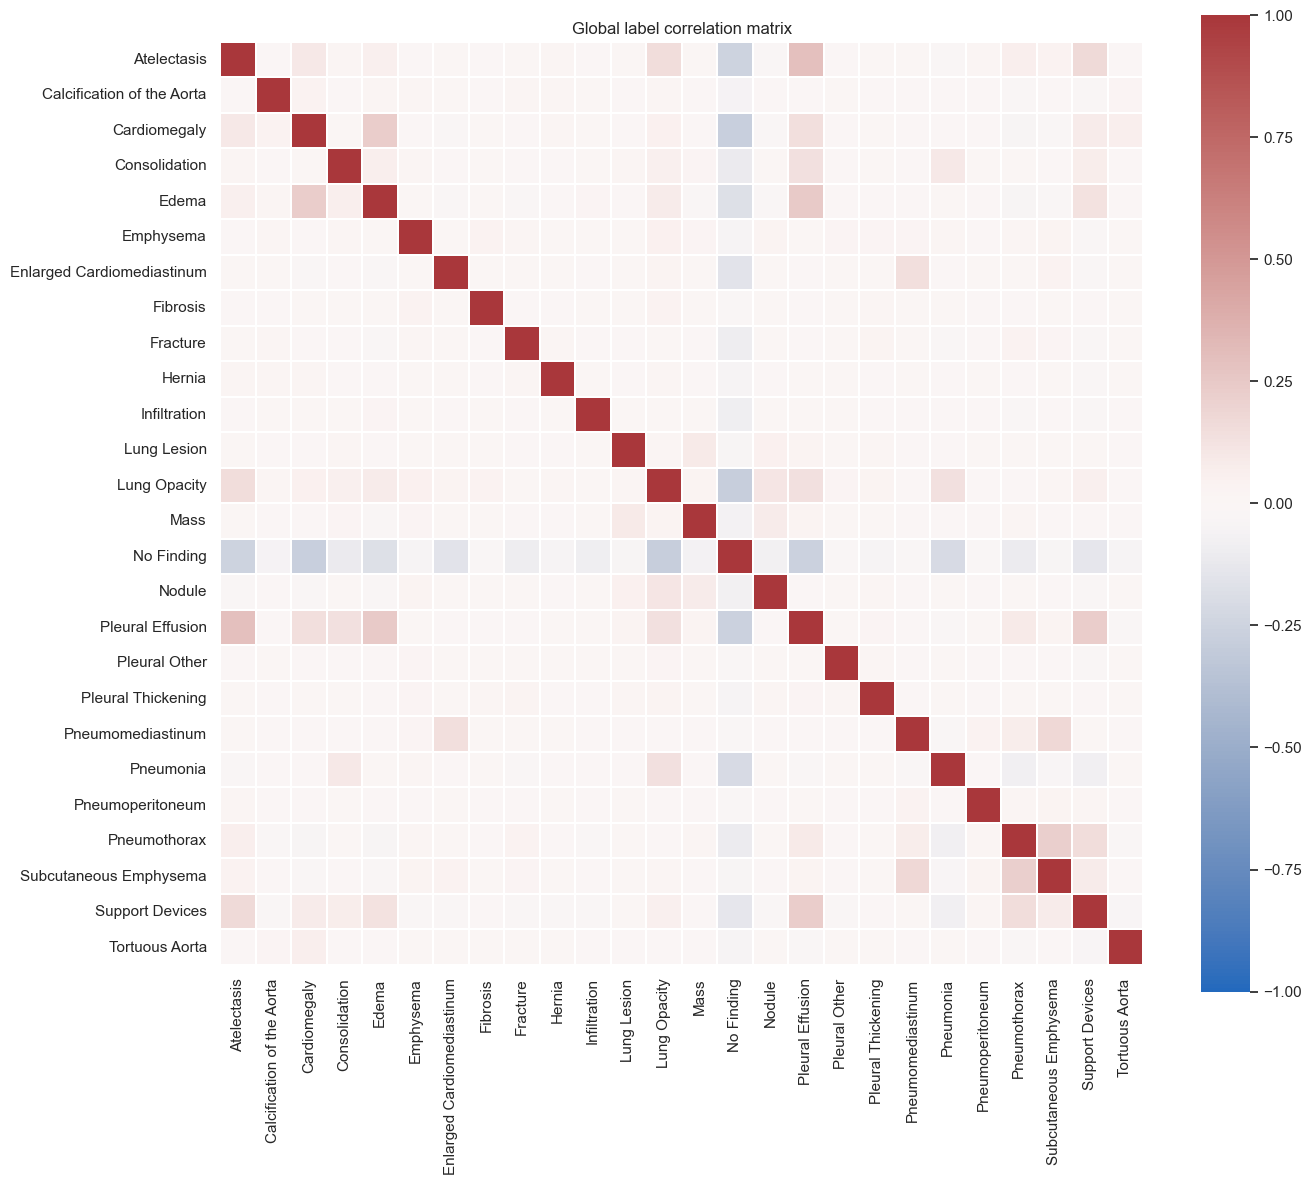

,left_label,right_label,correlation,cooccurrence_count,left_positive_count,right_positive_count
15,Atelectasis,Pleural Effusion,0.291589,46288,96311,98707
105,Edema,Pleural Effusion,0.247489,28928,55139,98707
50,Cardiomegaly,Edema,0.229485,29853,109297,55139
287,Pleural Effusion,Support Devices,0.229201,51132,98707,126776
319,Pneumothorax,Subcutaneous Emphysema,0.222111,2019,21129,3424
307,Pneumomediastinum,Subcutaneous Emphysema,0.179043,359,1122,3424
23,Atelectasis,Support Devices,0.169815,45570,96311,126776
320,Pneumothorax,Support Devices,0.153721,13401,21129,126776
11,Atelectasis,Lung Opacity,0.152220,40627,96311,114056
62,Cardiomegaly,Pleural Effusion,0.146287,39610,109297,98707


,left_label,right_label,correlation,cooccurrence_count,left_positive_count,right_positive_count
235,Lung Opacity,No Finding,-0.285610,0,114056,59714
60,Cardiomegaly,No Finding,-0.277093,0,109297,59714
260,No Finding,Pleural Effusion,-0.258270,0,59714,98707
13,Atelectasis,No Finding,-0.254026,0,96311,59714
264,No Finding,Pneumonia,-0.204036,0,59714,68327
103,Edema,No Finding,-0.179498,0,55139,59714
142,Enlarged Cardiomediastinum,No Finding,-0.155524,0,42960,59714
268,No Finding,Support Devices,-0.137518,11131,59714,126776
82,Consolidation,No Finding,-0.109935,0,22763,59714
266,No Finding,Pneumothorax,-0.105673,0,59714,21129


In [37]:
global_corr_df = global_df[label_cols].corr()
pair_corr_df = label_pair_correlation_table(global_df, label_cols)

plt.figure(figsize=(14, 12))
sns.heatmap(global_corr_df, cmap="vlag", center=0, vmin=-1, vmax=1, square=True, linewidths=0.2)
plt.title("Global label correlation matrix")
plt.tight_layout()
plt.show()

print("Most positively correlated label pairs")
display(pair_corr_df.sort_values("correlation", ascending=False).head(15))

print("Most negatively correlated label pairs")
display(pair_corr_df.sort_values("correlation", ascending=True).head(15))


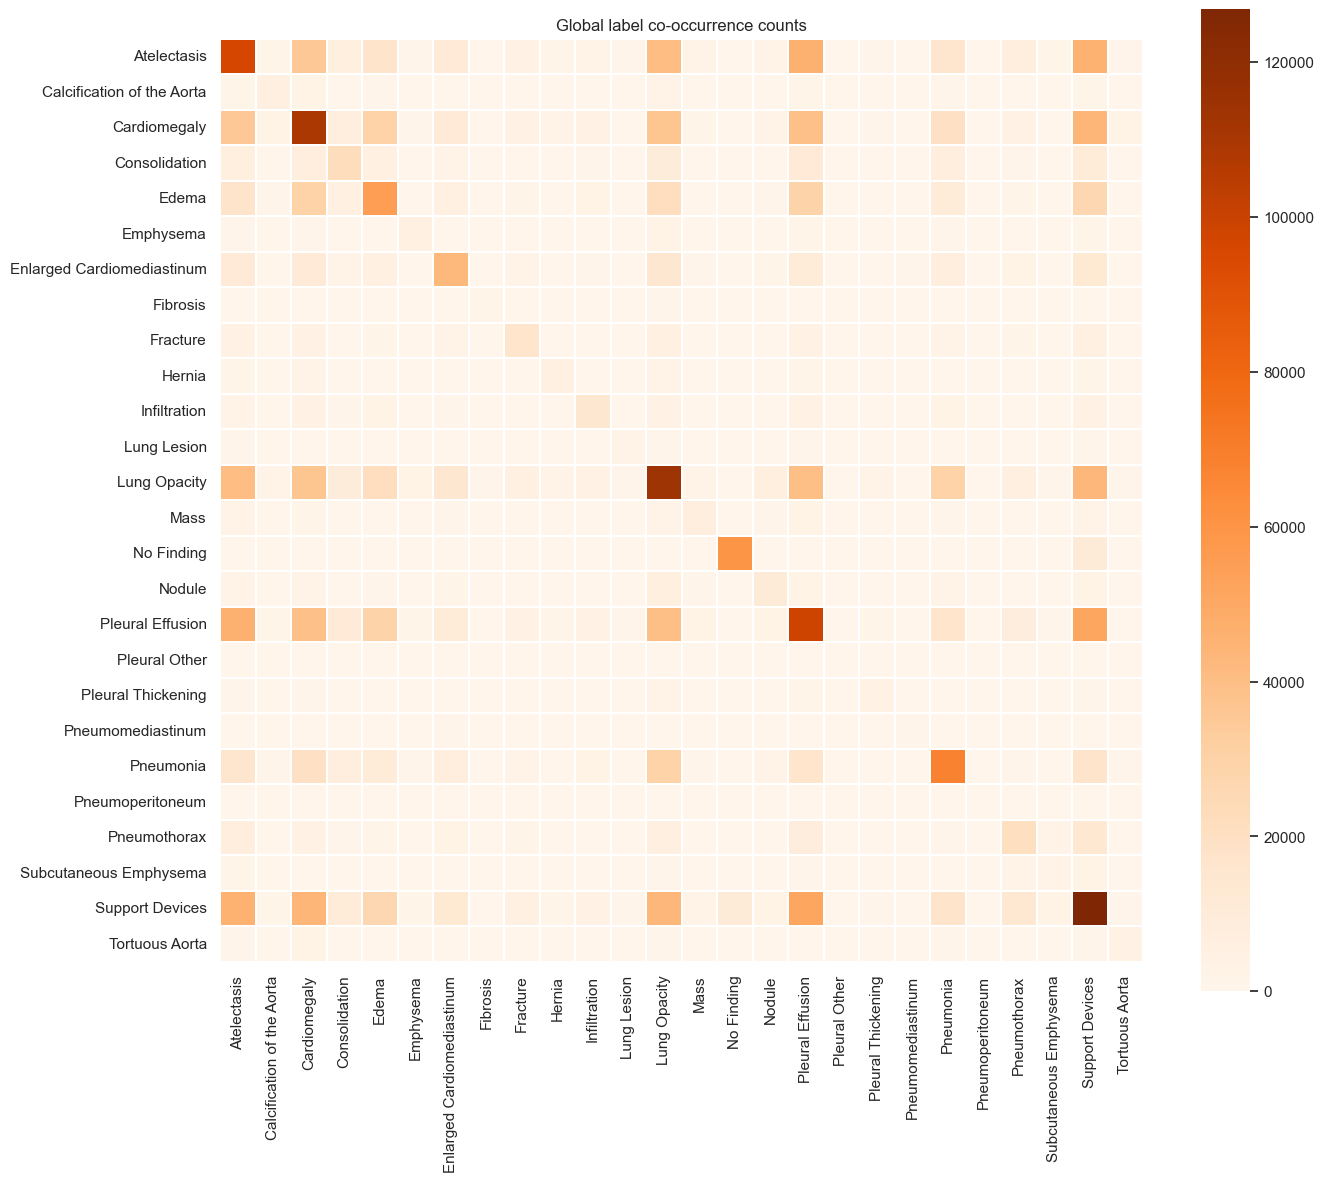

,Atelectasis,Calcification of the Aorta,Cardiomegaly,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fracture,Hernia
Atelectasis,96311,1539,35161,6452,17456,1378,11623,291,4627,1894
Calcification of the Aorta,1539,6258,2737,292,1187,232,750,28,472,197
Cardiomegaly,35161,2737,109297,7132,29853,1388,11517,534,4706,2094
Consolidation,6452,292,7132,22763,5427,549,2151,128,846,281
Edema,17456,1187,29853,5427,55139,897,5541,316,1788,736
Emphysema,1378,232,1388,549,897,5884,870,158,479,148
Enlarged Cardiomediastinum,11623,750,11517,2151,5541,870,42960,257,2069,811
Fibrosis,291,28,534,128,316,158,257,1758,66,23
Fracture,4627,472,4706,846,1788,479,2069,66,16993,423
Hernia,1894,197,2094,281,736,148,811,23,423,5838


In [38]:
global_cooccurrence_df = global_df[label_cols].T.dot(global_df[label_cols])

plt.figure(figsize=(14, 12))
sns.heatmap(
    global_cooccurrence_df.loc[label_cols, label_cols],
    cmap="Oranges",
    square=True,
    linewidths=0.2,
)
plt.title("Global label co-occurrence counts")
plt.tight_layout()
plt.show()

display(global_cooccurrence_df.loc[label_cols, label_cols].iloc[:10, :10])

## 8b) Conditional Co-Occurrence P(j|i) And Label-Graph Adjacency

Section 8 used Pearson/phi correlation, which is **symmetric and mean-centered**. On this dataset it is dominated by the large *No Finding* negative mass and badly understates structure for the rare classes — exactly the classes a label-correlation graph is supposed to rescue.

The statistic that actually matters for a label-graph head (ML-GCN / CheXGCN style, the family Duy Anh's GAT-margin-ranking belongs to) is the **conditional co-occurrence** `P(j | i) = N(i,j) / N(i)`: *given class i is present, how often is class j also present.* It is asymmetric and not centered, so a rare class with few positives can still have a sharp conditional profile that correlation hides.

This section computes, **train-split only** (a graph conditions the model, so it must never see dev/test):

1. **`P(j | i)`** — the conditional matrix.
2. **Lift `P(j | i) / P(j)`** — removes the "j is just common" effect. Lift ≈ 1 means the edge teaches nothing (it's just j's base rate); lift ≫ 1 means conditioning on i genuinely elevates j. This is the honest test of whether there is exploitable structure.
3. The **thresholded + re-weighted binary adjacency** an ML-GCN head would actually consume, plus how many classes end up *isolated* (no edge → the graph can't help them).

The verdict to read off this: do the **tail** classes have high-lift neighbours, or are they isolated? If isolated, the label graph mostly helps the already-common cardiogenic/air-leak clusters and is a minor ablation, not the v7 headline.


In [39]:
# --- Lift P(j|i)/P(j): does conditioning on i actually elevate j above its base rate? ---
counts = train_df[label_cols].sum()                  # P(j) denominator
co_counts = train_df[label_cols].T.dot(train_df[label_cols])
with np.errstate(divide="ignore", invalid="ignore"):
    cond_df = co_counts.div(counts.replace(0, np.nan), axis=0)
cond = cond_df.to_numpy()
base_rate = counts / len(train_df)                  # P(j) marginal
with np.errstate(divide="ignore", invalid="ignore"):
    lift = cond / base_rate.to_numpy()[None, :]
lift = np.nan_to_num(lift)
np.fill_diagonal(lift, np.nan)                      # ignore self
lift_df = pd.DataFrame(lift, index=label_cols, columns=label_cols)

def top_neighbours(row_label, k=4):
    s = lift_df.loc[row_label].dropna().sort_values(ascending=False).head(k)
    return ", ".join(
        f"{j} (lift {lift_df.loc[row_label, j]:.1f}, P={cond_df.loc[row_label, j]:.2f})"
        for j in s.index if lift_df.loc[row_label, j] >= 1.5
    ) or "(no neighbour with lift >= 1.5)"

# The tail classes are the ones a label graph is meant to rescue: do they have neighbours?
tail_classes = train_df[label_cols].sum().sort_values().head(10).index.tolist()
tail_view = pd.DataFrame({
    "class": tail_classes,
    "n_positive(train)": [int(counts.loc[c]) for c in tail_classes],
    "top_neighbours_by_lift": [top_neighbours(c) for c in tail_classes],
})
print("Tail classes — do they have informative (high-lift) neighbours to borrow from?")
display(tail_view)

# Overall structure density: what fraction of directed pairs carry real signal?
n_pairs = len(label_cols) * (len(label_cols) - 1)
for thr in (1.5, 2.0, 3.0):
    n = int(np.nansum(lift_df.to_numpy() >= thr))
    print(f"directed pairs with lift >= {thr}: {n} / {n_pairs} = {100 * n / n_pairs:.1f}%")

,class,n_positive(train),top_neighbours_by_lift
0,Pneumoperitoneum,543,"Pneumomediastinum (lift 14.2, P=0.04), Subcuta..."
1,Pleural Other,675,"Emphysema (lift 4.8, P=0.08), Pleural Thickeni..."
2,Pneumomediastinum,788,"Subcutaneous Emphysema (lift 32.2, P=0.30), Pn..."
3,Fibrosis,1158,"Emphysema (lift 5.3, P=0.08), Pleural Thickeni..."
4,Subcutaneous Emphysema,2453,"Pneumomediastinum (lift 32.2, P=0.10), Pneumot..."
5,Lung Lesion,2533,"Mass (lift 7.2, P=0.15), Pneumoperitoneum (lif..."
6,Pleural Thickening,3369,"Pleural Other (lift 4.1, P=0.01), Fibrosis (li..."
7,Tortuous Aorta,3499,"Calcification of the Aorta (lift 3.1, P=0.05),..."
8,Hernia,4049,"Pleural Other (lift 2.2, P=0.01), Pneumoperito..."
9,Emphysema,4255,"Fibrosis (lift 5.3, P=0.02), Pleural Other (li..."


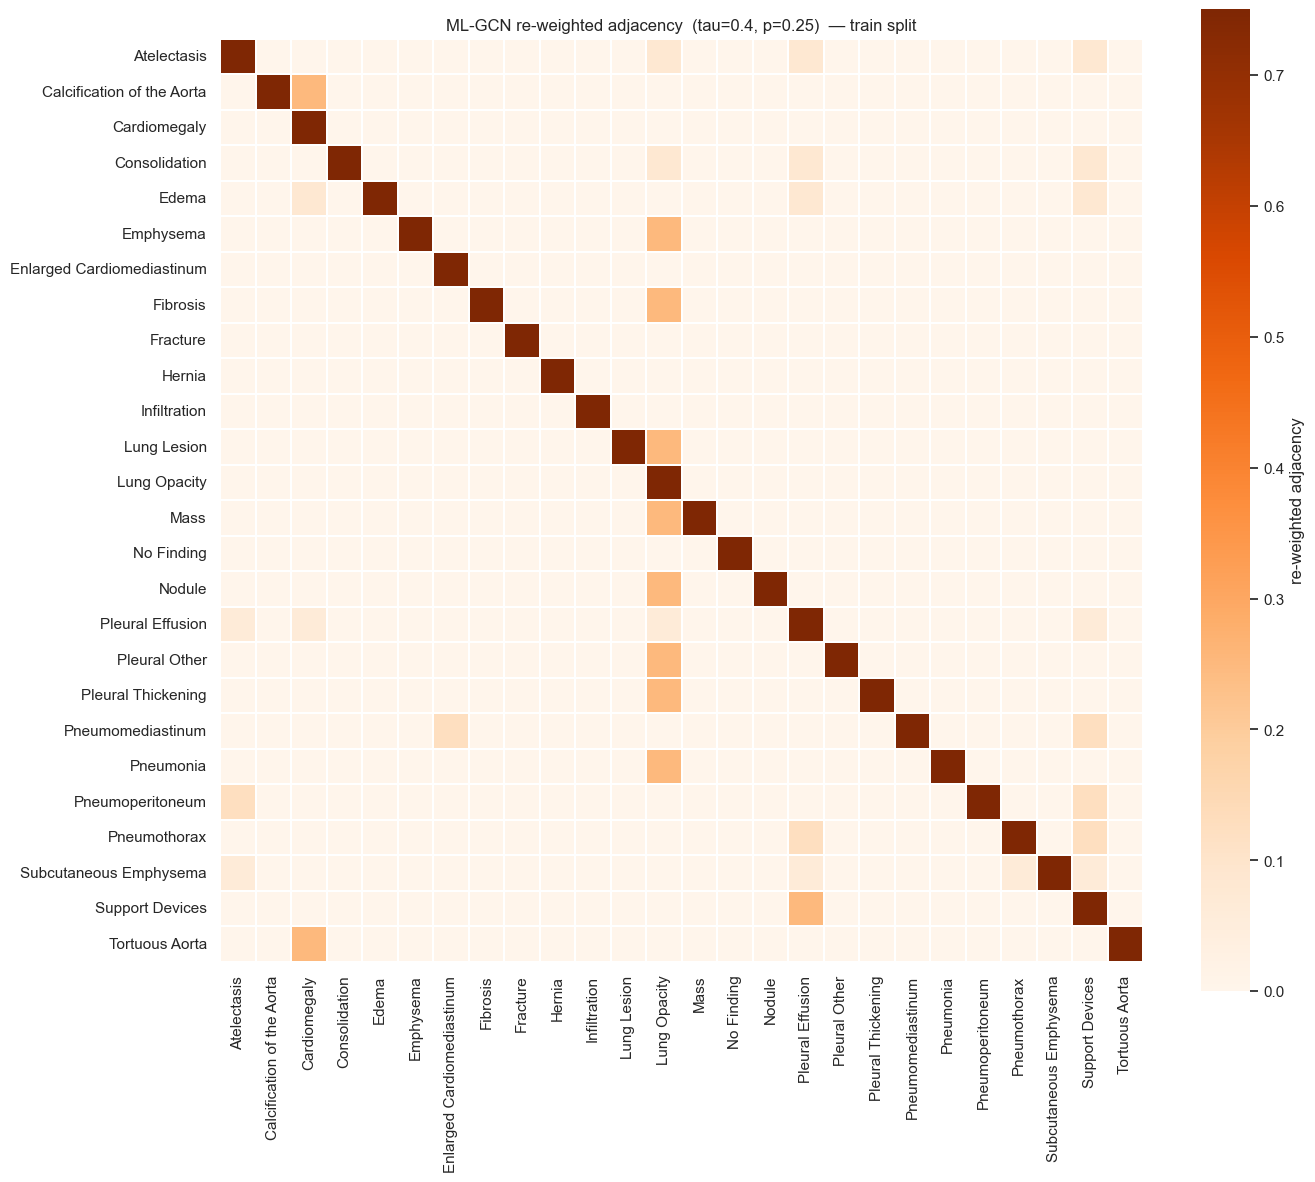

In [40]:
# --- ML-GCN re-weighted adjacency (Chen et al., CVPR 2019): the graph a v7 head would consume ---
# Binarize P(j|i) at tau, then re-weight so each node keeps mass (1-p) on itself and p spread
# over its neighbours -- this is the over-smoothing fix from the ML-GCN paper.
tau = 0.4   # drop edges with P(j|i) < tau
p = 0.25    # neighbour mass (self keeps 1-p)

A_bin = (cond_df.to_numpy() >= tau).astype(float)
np.fill_diagonal(A_bin, 0.0)

deg = A_bin.sum(axis=1, keepdims=True)
with np.errstate(divide="ignore", invalid="ignore"):
    A_rw = p * A_bin / deg
A_rw = np.nan_to_num(A_rw)
np.fill_diagonal(A_rw, 1.0 - p)
A_rw_df = pd.DataFrame(A_rw, index=label_cols, columns=label_cols)

n_edges = int(A_bin.sum())
isolated = [label_cols[i] for i in range(len(label_cols)) if A_bin[i].sum() == 0]
print(f"tau={tau}, p={p}")
print(f"directed edges after threshold: {n_edges} / {len(label_cols) * (len(label_cols) - 1)}")
print(f"isolated classes (no outgoing edge -> graph teaches them nothing): {len(isolated)}/{len(label_cols)}")
print(sorted(isolated))

plt.figure(figsize=(14, 12))
sns.heatmap(
    A_rw_df.loc[label_cols, label_cols], cmap="Oranges", square=True, linewidths=0.2,
    cbar_kws={"label": "re-weighted adjacency"},
)
plt.title(f"ML-GCN re-weighted adjacency  (tau={tau}, p={p})  — train split")
plt.tight_layout()
plt.show()

## 9) View-Conditioned Prevalence

This compares label rates for `AP`, `PA`, and `LATERAL`. It is useful for checking whether a label is view-dependent enough that frontal and lateral encoders should be treated separately.


,split,ViewPosition,row_count
78,development,AP,14478
104,development,LATERAL,8239
130,development,PA,9305
156,test,AP,29383
182,test,LATERAL,16596
208,test,PA,19297
0,train,AP,103312
26,train,LATERAL,58018
52,train,PA,67559


,scope,ViewPosition,row_count
0,global,AP,147173
26,global,LATERAL,82853
52,global,PA,96161


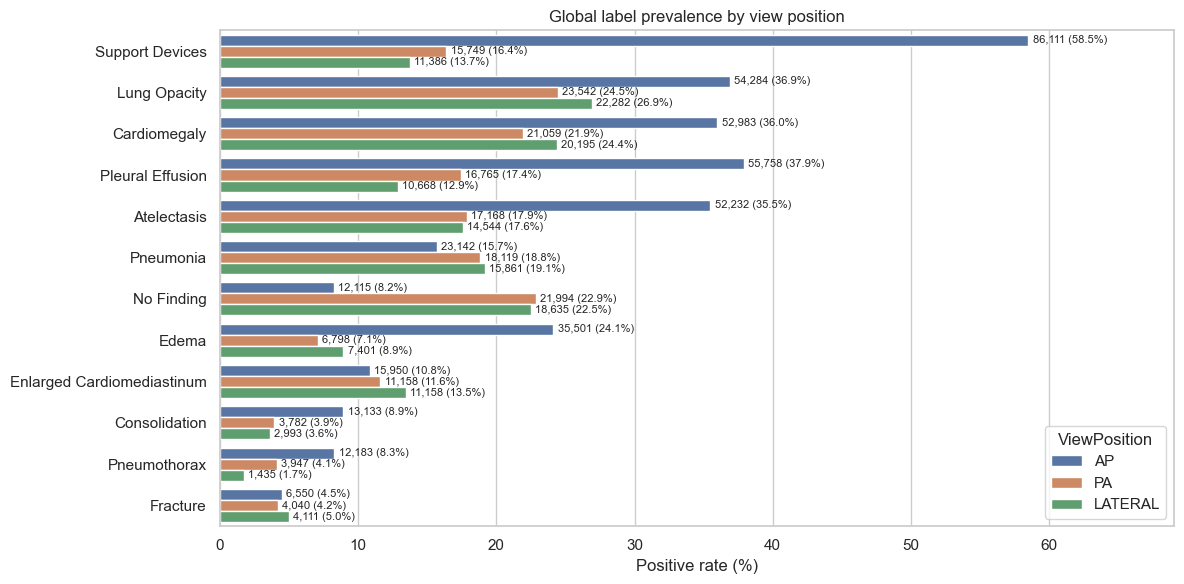

ViewPosition,AP,LATERAL,PA
label,,,
Support Devices,58.510,13.742,16.378
Lung Opacity,36.884,26.893,24.482
Cardiomegaly,36.000,24.374,21.900
Pleural Effusion,37.886,12.876,17.434
Atelectasis,35.490,17.554,17.853
Pneumonia,15.724,19.144,18.842
No Finding,8.232,22.492,22.872
Edema,24.122,8.933,7.069
Enlarged Cardiomediastinum,10.838,13.467,11.603


In [41]:
view_prevalence_df = view_conditioned_prevalence(analysis_splits, label_cols)
global_view_prevalence_df = view_conditioned_prevalence(global_frames, label_cols)

view_counts_df = (
    view_prevalence_df[["split", "ViewPosition", "row_count"]]
    .drop_duplicates()
    .sort_values(["split", "ViewPosition"])
)
global_view_counts_df = (
    global_view_prevalence_df[["split", "ViewPosition", "row_count"]]
    .drop_duplicates()
    .rename(columns={"split": "scope"})
    .sort_values(["scope", "ViewPosition"])
)

display(view_counts_df)
display(global_view_counts_df)

top_global_labels = global_df[label_cols].sum().sort_values(ascending=False).head(12).index.tolist()
plot_view_conditioned_prevalence(
    global_view_prevalence_df,
    label_order=top_global_labels,
    title="Global label prevalence by view position",
)

display(
    global_view_prevalence_df
    .query("label in @top_global_labels")
    .pivot(index="label", columns="ViewPosition", values="positive_rate_pct")
    .loc[top_global_labels]
    .round(3)
)


## 10) Image Availability And Path Sanity

CXR-LT `path` values are relative to the MIMIC-CXR-JPG root. This checks whether the expected JPG files are present locally before dataloader work.


In [42]:
image_root = mimic_cxr_jpg_dir
print(f"image_root: {image_root}")
print(f"image_root exists: {image_root.exists()}")
print(f"image files directory exists: {(image_root / 'files').exists()}")

image_path_summary_df = summarize_image_paths(analysis_splits, image_root)
global_image_path_summary_df = summarize_image_paths(global_frames, image_root).rename(columns={"split": "scope"})

display(image_path_summary_df)
display(global_image_path_summary_df)

missing_global_paths = global_df.loc[
    ~global_df["path"].astype(str).map(lambda value: resolve_relative_path(image_root, value).is_file()),
    ["source_split", "dicom_id", "subject_id", "study_id", "ViewPosition", "path"],
].head(10)

print("Sample missing global image paths")
display(missing_global_paths)


,split,rows,path_column,path_values,unique_paths,duplicate_path_rows,jpg_extension_rows,existing_files,missing_files,existing_file_pct
0,train,264849,path,264849,264849,0,264849,264849,0,100.0
1,development,36769,path,36769,36769,0,36769,36769,0,100.0
2,test,75492,path,75492,75492,0,75492,75492,0,100.0


,scope,rows,path_column,path_values,unique_paths,duplicate_path_rows,jpg_extension_rows,existing_files,missing_files,existing_file_pct
0,global,377110,path,377110,377110,0,377110,377110,0,100.0


,source_split,dicom_id,subject_id,study_id,ViewPosition,path


## 11) Text Linkage Readiness

This joins CXR-LT studies to the MIMIC-CXR study list. A successful index join means the label row can be paired to a report path. File existence is a separate check because this workstation may have metadata without the report text tree.


In [43]:
study_list_df, study_list_path = load_first_existing(
    [
        mimic_cxr_dir / "cxr-study-list.csv.gz",
        mimic_cxr_dir / "cxr-study-list.csv",
    ]
)

if study_list_df is None:
    print("MIMIC-CXR study list was not found. Report linkage cannot be checked.")
    report_link_summary_df = pd.DataFrame()
    global_report_link_summary_df = pd.DataFrame()
    linked_reports_df = pd.DataFrame()
    global_linked_reports_df = pd.DataFrame()
else:
    print(f"Loaded study list: {study_list_path}")
    (
        report_link_summary_df,
        global_report_link_summary_df,
        linked_reports_df,
        global_linked_reports_df,
    ) = build_report_linkage(analysis_splits, global_df, study_list_df, mimic_cxr_dir)

    print(f"report files directory exists: {(mimic_cxr_dir / 'files').exists()}")
    display(report_link_summary_df)
    display(global_report_link_summary_df)
    display(linked_reports_df.head(10))


,split,studies,studies_with_report_index,studies_with_report_file,report_index_pct,report_file_pct
0,development,22291,22291,22274,100.0,99.923736
1,test,45492,45492,45472,100.0,99.956036
2,train,160052,160052,159959,100.0,99.941894


,scope,studies,studies_with_report_index,studies_with_report_file,report_index_pct,report_file_pct
0,global,227835,227835,227705,100.0,99.942941


,subject_id,study_id,study_id_norm,split,report_path,has_report_index,report_file_exists
0,10000032,50414267,50414267,train,files/p10/p10000032/s50414267.txt,True,True
1,10000032,53189527,53189527,train,files/p10/p10000032/s53189527.txt,True,True
2,10000032,53911762,53911762,train,files/p10/p10000032/s53911762.txt,True,True
3,10000032,56699142,56699142,train,files/p10/p10000032/s56699142.txt,True,True
4,10000764,57375967,57375967,train,files/p10/p10000764/s57375967.txt,True,True
5,10000898,50771383,50771383,train,files/p10/p10000898/s50771383.txt,True,True
6,10000898,54205396,54205396,train,files/p10/p10000898/s54205396.txt,True,True
7,10000980,50985099,50985099,train,files/p10/p10000980/s50985099.txt,True,True
8,10000980,51967283,51967283,train,files/p10/p10000980/s51967283.txt,True,True
9,10000980,54577367,54577367,train,files/p10/p10000980/s54577367.txt,True,True


In [44]:
if global_linked_reports_df.empty or not global_linked_reports_df["report_file_exists"].any():
    print("No local report text files were found to preview.")
else:
    sample_report_row = global_linked_reports_df.query("report_file_exists").iloc[0]
    print(
        "Sample report: "
        f"subject_id={sample_report_row['subject_id']}, "
        f"study_id={sample_report_row['study_id']}"
    )
    print(read_report_text(mimic_cxr_dir, sample_report_row["report_path"]))


## Notes For The Next Modeling Pass

Use these outputs to decide whether the modular dataloader should preserve study-level grouping, whether paired frontal/lateral samples are common enough to require special batching, and whether the local machine has the image/report files required for multimodal experiments.
